### About the dataset

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers

I'll use unsupervised learning algorithms to find the hidden patterns of dataset, to use them later in business for the customer type clustering.

E.g. company can use it to understand which customers are at risk of quiting the service and it'll help company to start reactivation campaign or stop spending budget on them.

On the other side if customer is buying a lot, company can make personalized offer to increase their products selling even more.

---

### Import & Basic analysis

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [55]:
df = pd.read_csv("../data/raw/online_retail_II.csv")

In [56]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [57]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [58]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(34335)

In [60]:
df.shape

(1067371, 8)

### Handling missing values

In [61]:
df = df.drop(columns=['Description'])

`Description feature` doesn't represent any useful information, so i'll drop it

In [62]:
print(f"NA values are {df["Customer ID"].isna().mean().round(3) * 100}% of whole dataset")

NA values are 22.8% of whole dataset


NA values of `Customer ID` will be dropped, even though it's almost 1/4 of dataset.

The reason for it - is that for our task it's must-have to know which customer bought which product, because in other way we won't be able to determine clusters precisely.

In [63]:
df = df.dropna(subset=['Customer ID'])

In [64]:
df.isna().sum().any()

np.False_

### Handling duplicates

In [65]:
df[df.duplicated(keep=False)].sort_values(
    ["Invoice", "StockCode", "Customer ID"]
).head(6)

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


They represent the same information, so it's reasonable to drop them so they don't distort the model.

In [66]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print(f"Removed: {before - after:,}")
print(f"Remaining rows: {after:,}")

Removed: 26,481
Remaining rows: 797,883


In [67]:
df.duplicated().any()

np.False_

---

### Handling cancellations and values under zero

If `Invoice` starts with `C` it means the order was cancelled, e.g. `C489xxx`.

In [68]:
df['is_cancelled'] = df['Invoice'].astype(str).str.startswith('C')

In [69]:
df.groupby("is_cancelled")["Quantity"].agg(["count", "mean", "sum"])

,count,mean,sum
is_cancelled,,,
False,779493,13.506731,10528402
True,18390,-25.719195,-472976


In [70]:
df['sum_cancelled_orders'] = (
    df.groupby('Customer ID')['Invoice']
      .transform(lambda inv: inv.where(df['is_cancelled']).nunique())
)

I created `sum_cancelled_orders` - the number of unique orders each customer cancelled. Useful later for churn-risk analysis.

I noticed the mean of quantity is negative, so we must inspect it. Before that I'll drop the line-level `is_cancelled` flag, since it's not a supervised label.

In [71]:
df = df.drop(columns=['is_cancelled'])

---

In [72]:
(df["Quantity"] < 0).sum()

np.int64(18390)

In [73]:
(df["Price"] <= 0).sum()

np.int64(70)

Price is also somehow negative and must be handled.

In [74]:
df[df["Price"] <= 0][
    ["Invoice", "StockCode", "Quantity", "Price"]
].head(20)

,Invoice,StockCode,Quantity,Price
4674,489825,22076,12,0.0
6781,489998,48185,2,0.0
16107,490727,M,1,0.0
18738,490961,22065,1,0.0
18739,490961,22142,12,0.0
32916,492079,85042,8,0.0
40101,492760,21143,12,0.0
47126,493761,79320,24,0.0
48342,493899,22355,10,0.0
57619,494607,21533,12,0.0


In [75]:
df[df["Quantity"] <= 0][
    ["Invoice", "StockCode", "Quantity", "Price"]
].head(20)

,Invoice,StockCode,Quantity,Price
178,C489449,22087,-12,2.95
179,C489449,85206A,-6,1.65
180,C489449,21895,-4,4.25
181,C489449,21896,-6,2.10
182,C489449,22083,-12,2.95
183,C489449,21871,-12,1.25
184,C489449,84946,-12,1.25
185,C489449,84970S,-24,0.85
186,C489449,22090,-12,2.95
196,C489459,90200A,-3,4.25


Those rows are invalid and must be dropped, because price zero can't exist and StockCode `like TEST001 and M` shows that those could be just bugs, tests or cancelled rows

In [76]:
df = df[(df['Price'] > 0) & (df['Quantity'] > 0)]

In [77]:
(df['Quantity'] <= 0).any() | (df['Price'] <= 0).any()

np.False_

---

### Outliers handling

Let's create Revenue feature which will be pretty useful in the future, since it's the combination of Quanitity and Price

In [78]:
df['Revenue'] = df['Quantity'] * df['Price']

In [79]:
df["Quantity"].describe()

count    779423.000000
mean         13.489016
std         145.855640
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [80]:
df["Price"].describe()

count    779423.000000
mean          3.218488
std          29.676178
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64

I noticed those two features has the biggest gap between min and max values

In [81]:
df.nlargest(20, "Quantity")[
    ["Invoice", "StockCode", "Quantity", "Price", "Customer ID"]
]

,Invoice,StockCode,Quantity,Price,Customer ID
1065882,581483,23843,80995,2.08,16446.0
587080,541431,23166,74215,1.04,12346.0
90857,497946,37410,19152,0.10,13902.0
127166,501534,21099,12960,0.10,13902.0
127168,501534,21091,12960,0.10,13902.0
127169,501534,21085,12744,0.10,13902.0
127167,501534,21092,12480,0.10,13902.0
135027,502269,21984,10000,0.25,17940.0
135028,502269,21982,10000,0.25,17940.0
135029,502269,21980,10000,0.25,17940.0


In [82]:
df.nlargest(20, "Price")[
    ["Invoice", "StockCode", "Quantity", "Price", "Customer ID"]
]

,Invoice,StockCode,Quantity,Price,Customer ID
135013,502263,M,1,10953.50,12918.0
358639,524159,M,1,10468.80,14063.0
74356,496115,M,1,8985.60,17949.0
698843,551697,POST,1,8142.75,16029.0
129903,501766,M,1,6958.17,15760.0
129987,501768,M,1,6958.17,15760.0
947835,573077,M,1,4161.06,12536.0
947838,573080,M,1,4161.06,12536.0
931867,571751,M,1,3949.32,12744.0
288706,517483,M,1,3610.50,12737.0


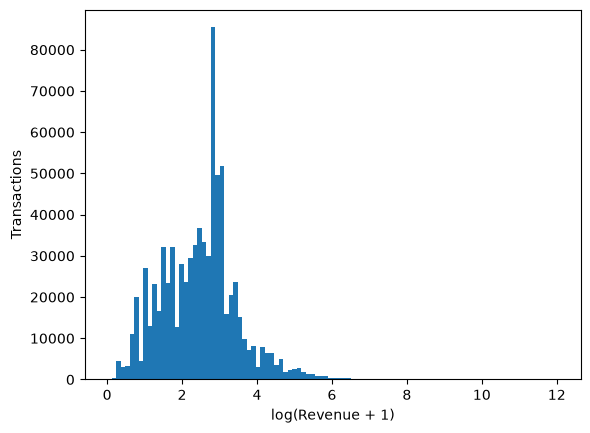

In [83]:
plt.hist(np.log1p(df["Revenue"]), bins=100)
plt.xlabel("log(Revenue + 1)")
plt.ylabel("Transactions")
plt.show()

In [84]:
Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Revenue"] < lower) |
    (df["Revenue"] > upper)
]

len(outliers)

63561

The product-outliers in this dataset are either:
- very cheap and sold in very high quantity

- very expensive and sold once

Which represents normal product sales and can't be dropped.

---

### Categorical features analysis

In [85]:
cat_cols = ['StockCode', 'Country', 'Customer ID', 'Invoice']

df[cat_cols].nunique()

StockCode       4631
Country           41
Customer ID     5878
Invoice        36969
dtype: int64

In [86]:
df['Country'].value_counts(normalize=True) * 100

Country
United Kingdom          89.859550
Germany                  2.108226
EIRE                     1.996990
France                   1.733462
Netherlands              0.652406
Spain                    0.469835
Belgium                  0.391957
Switzerland              0.385542
Portugal                 0.302275
Australia                0.229529
Channel Islands          0.198993
Italy                    0.185009
Sweden                   0.168971
Norway                   0.165379
Cyprus                   0.145749
Finland                  0.132406
Austria                  0.118293
Denmark                  0.099817
Greece                   0.084293
Unspecified              0.066459
Poland                   0.064663
Japan                    0.060044
USA                      0.052475
United Arab Emirates     0.049139
Singapore                0.043494
Israel                   0.040928
Malta                    0.036181
Canada                   0.029252
Iceland                  0.028483
Lithua

Instead of encoding this feature I'll drop it because almost 90% of the orders came from UK and country based analysis in our case would be very unnecessary.

ID based features can't be dropped because it'll be used in separating cases between each other.

In [87]:
df = df.drop(columns=['Country'])

---

### Wrong dtypes

In [88]:
df.dtypes

Invoice                  object
StockCode                object
Quantity                  int64
InvoiceDate              object
Price                   float64
Customer ID             float64
sum_cancelled_orders      int64
Revenue                 float64
dtype: object

In [89]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
nat = df['InvoiceDate'].isna().sum()
print(f'Coerced to NaT: {nat}')

Coerced to NaT: 0


### Feature engineering  

In [90]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,sum_cancelled_orders,Revenue
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,2,83.4
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,2,81.0
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,2,81.0
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,2,100.8
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,2,30.0


---

#### Behavioral features.

In [91]:
df['avg_order_value'] = df.groupby(['Customer ID', 'Invoice'])['Revenue'].transform('sum').groupby(df['Customer ID']).transform('mean')

df['avg_items_per_order'] = df.groupby(['Customer ID', 'Invoice'])['Quantity'].transform('sum').groupby(df['Customer ID']).transform('mean')

behavioral_features = (
    df.groupby('Customer ID')
      .agg(
          num_orders=('Invoice', 'nunique'),
          num_products=('StockCode', 'nunique'),
          total_items=('Quantity', 'sum'),
          avg_unit_price=('Price', 'mean'),
          total_revenue=('Revenue', 'sum'),
          sum_cancelled_orders=('sum_cancelled_orders', 'max'),
      )
      .reset_index()
)

In [92]:
df = (
    df.drop(columns=['sum_cancelled_orders'])
      .merge(behavioral_features, on='Customer ID')
)

---

#### Date features

In [93]:
datetime_features = (
    df.groupby('Customer ID')['InvoiceDate']
      .agg(
          first_purchase='min',
          last_purchase='max'
      ).reset_index()
)

Time from last purchase

In [94]:
datetime_features['customer_lifetime_days'] = (
    datetime_features['last_purchase']
    - datetime_features['first_purchase']
).dt.days

In [95]:
reference_date = df['InvoiceDate'].max()

datetime_features['recency_days'] = (
    reference_date
    - datetime_features['last_purchase']
).dt.days

In [96]:
orders = (
    df.groupby('Customer ID')['Invoice']
      .nunique()
      .rename('num_orders')
      .reset_index()
)

datetime_features = datetime_features.merge(
    orders,
    on='Customer ID'
)

datetime_features['purchase_frequency'] = (
    datetime_features['num_orders']
    / (datetime_features['customer_lifetime_days'] / 30.44).clip(lower=1)
)

In [97]:
datetime_features = datetime_features.drop(
    columns=['first_purchase', 'last_purchase', 'num_orders']
)

In [98]:
df = pd.merge(df, datetime_features, on='Customer ID')

In [99]:
df.head(5)

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Revenue,avg_order_value,avg_items_per_order,num_orders,num_products,total_items,avg_unit_price,total_revenue,sum_cancelled_orders,customer_lifetime_days,recency_days,purchase_frequency
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,83.4,350.900238,138.928571,8,50,944,3.561071,2433.28,2,581,157,0.419139
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,81.0,350.900238,138.928571,8,50,944,3.561071,2433.28,2,581,157,0.419139
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,81.0,350.900238,138.928571,8,50,944,3.561071,2433.28,2,581,157,0.419139
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,100.8,350.900238,138.928571,8,50,944,3.561071,2433.28,2,581,157,0.419139
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,30.0,350.900238,138.928571,8,50,944,3.561071,2433.28,2,581,157,0.419139


---

### EDA

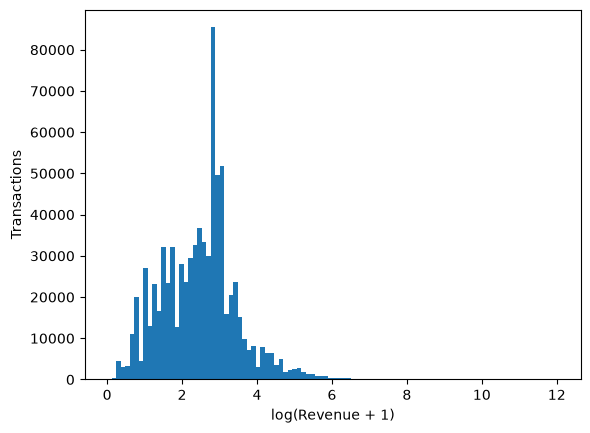

In [105]:
plt.hist(np.log1p(df["Revenue"]), bins=100)
plt.xlabel("log(Revenue + 1)")
plt.ylabel("Transactions")
plt.show()

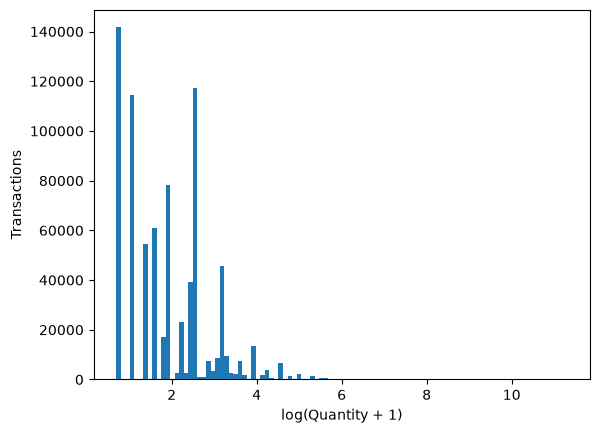

In [107]:
plt.hist(np.log1p(df["Quantity"]), bins=100)
plt.xlabel("log(Quantity + 1)")
plt.ylabel("Transactions")
plt.show()

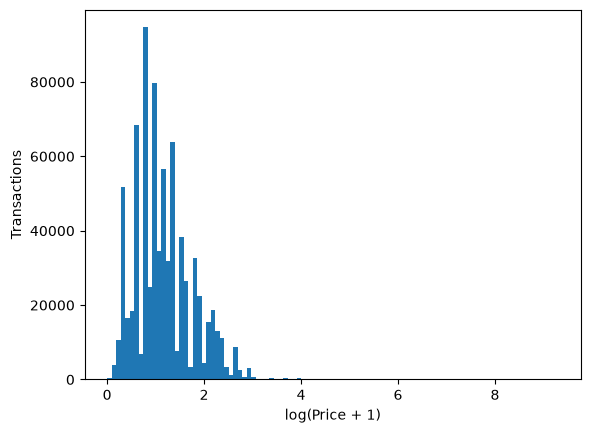

In [103]:
plt.hist(np.log1p(df["Price"]), bins=100)
plt.xlabel("log(Price + 1)")
plt.ylabel("Transactions")
plt.show()

Plots are so right-skewed that I had to use log in x-axis.

In [ ]:
rfm = df.groupby("Customer ID").agg(
    # Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    Recency=("InvoiceDate", lambda x: (df["InvoiceDate"].max() - x.max()).days)
)